In [ ]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
#2. Download Dataset
import kagglehub

path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

print("Dataset path:", path)


Dataset path: C:\Users\LENOVO\.cache\kagglehub\datasets\lainguyn123\student-performance-factors\versions\9


In [2]:
import os

print(os.listdir(path))

['StudentPerformanceFactors.csv']


In [ ]:
# 2. Load Dataset

import pandas as pd

file_path = os.path.join(path, "StudentPerformanceFactors.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# view the first five rows of the dataset
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
#view the shape of the dataset
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset shape: (6607, 20)

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence            

In [ ]:
#find missing values in the dataset
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [ ]:
# coping the original dataframe to a new dataframe for cleaning and preprocessing
df_clean = df.copy()

In [ ]:
# Fill missing values in categorical columns with the mode
categorical_columns = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].mode()[0]
    )

In [ ]:
# correct the "Exam_Score" column by replacing values greater than 100 with 100
df_clean.loc[
    df_clean["Exam_Score"] > 100,
    "Exam_Score"
] = 100

In [ ]:
# verify the changes made to the "Exam_Score" column
print("Maximum Exam Score:", df_clean["Exam_Score"].max())
print(
    "Scores above 100:",
    (df_clean["Exam_Score"] > 100).sum()
)

Maximum Exam Score: 100
Scores above 100: 0


In [ ]:
# view the description of the cleaned dataset
print(df_clean.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235508  
std             1.230570           1.031231     3.889161  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

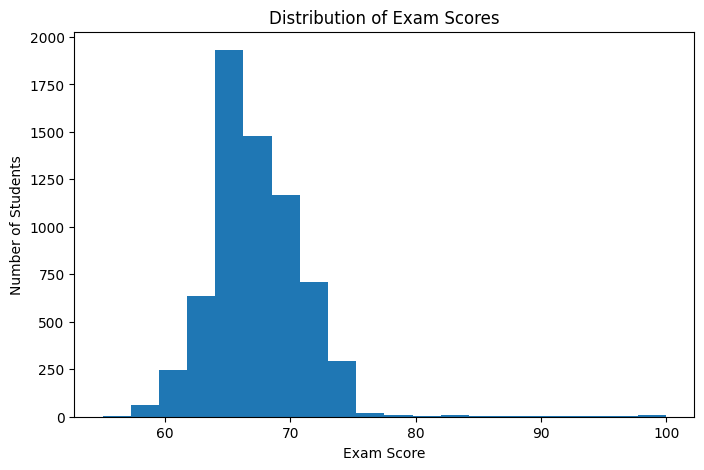

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["Exam_Score"], bins=20)

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()

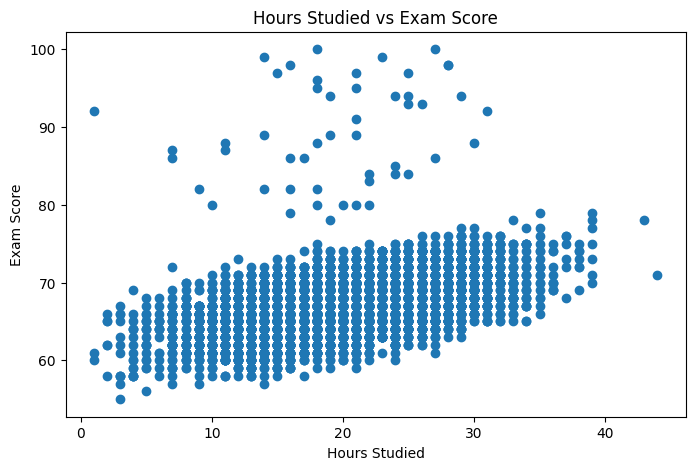

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Hours_Studied"],
    df_clean["Exam_Score"]
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")

plt.show()

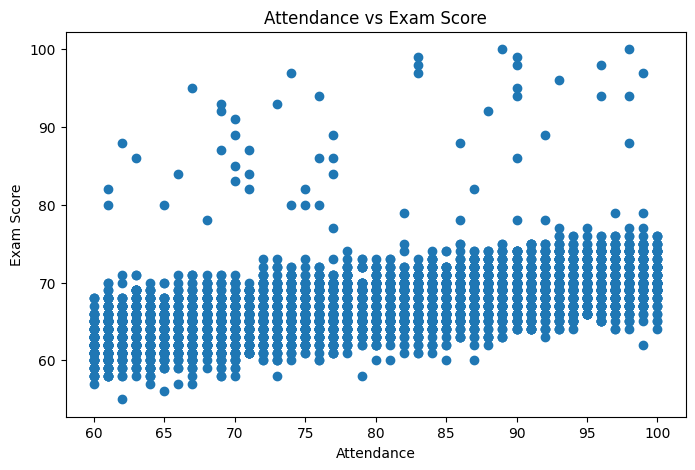

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Attendance"],
    df_clean["Exam_Score"]
)

plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")

plt.show()

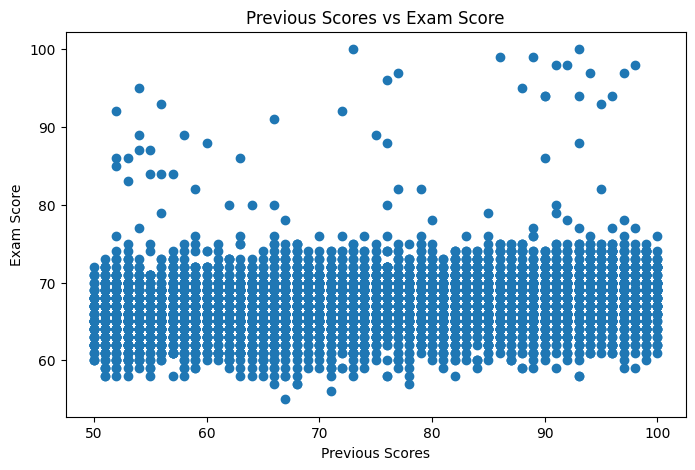

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Previous_Scores"],
    df_clean["Exam_Score"]
)

plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.title("Previous Scores vs Exam Score")

plt.show()

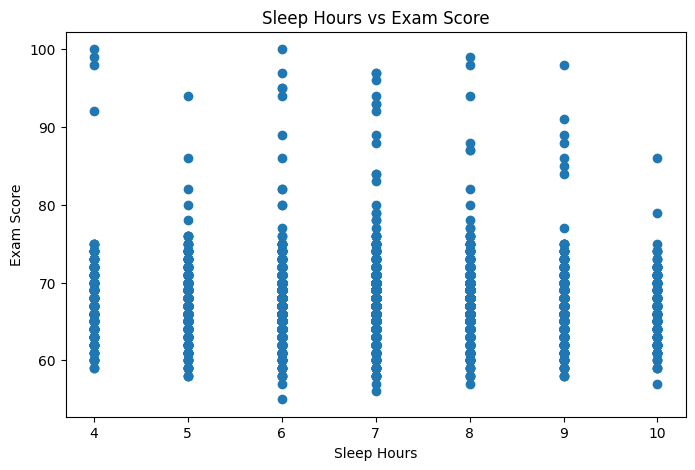

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Sleep_Hours"],
    df_clean["Exam_Score"]
)

plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")
plt.title("Sleep Hours vs Exam Score")

plt.show()

In [19]:
correlation = df_clean.corr(numeric_only=True)

print(
    correlation["Exam_Score"]
    .sort_values(ascending=False)
)

Exam_Score           1.000000
Attendance           0.581205
Hours_Studied        0.445558
Previous_Scores      0.175089
Tutoring_Sessions    0.156466
Physical_Activity    0.027832
Sleep_Hours         -0.017000
Name: Exam_Score, dtype: float64


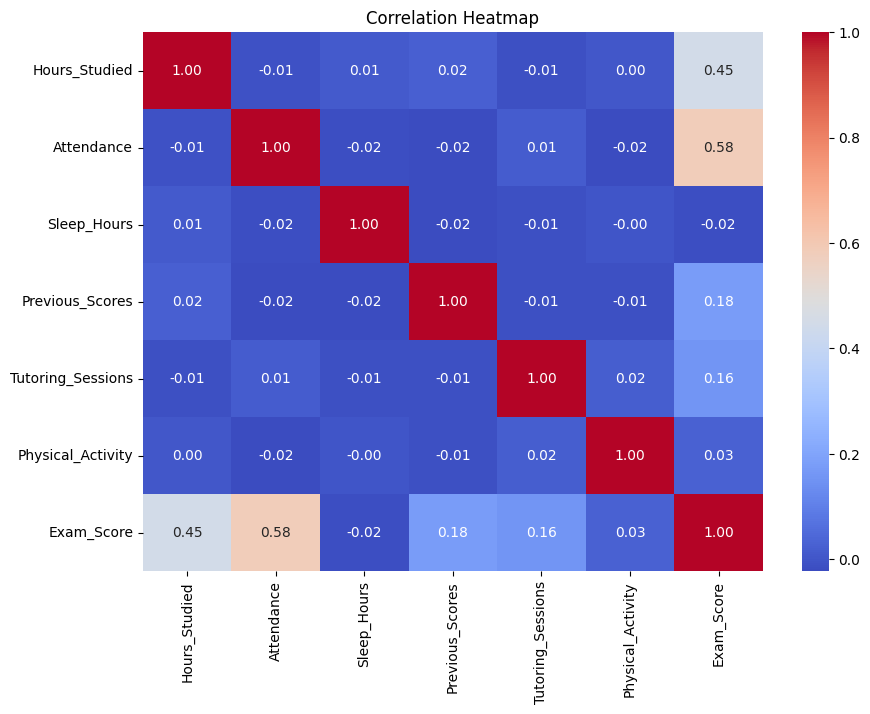

In [20]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
features = df_clean.drop("Exam_Score", axis=1)

target = df_clean["Exam_Score"]

print("Features shape:", features.shape)
print("Target shape:", target.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [ ]:
# Identify numerical and categorical features
numerical_features = features.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = features.select_dtypes(
    include=["object"]
).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [ ]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5285, 19)
Testing features: (1322, 19)
Training target: (5285,)
Testing target: (1322,)


In [ ]:
# Preprocessing: One-Hot Encoding for Categorical Features
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
# Apply the preprocessor to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (5285, 40)
Testing data after preprocessing: (1322, 40)


In [ ]:
# Train a Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


In [ ]:
# Train the model
model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
# Generate predictions on the test set
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[64.52785807 65.26336271 71.53164044 64.27757485 66.52081547 66.61146501
 72.46949846 66.49821844 69.98621545 70.1343529 ]


In [ ]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.4522783731867862
Mean Squared Error (MSE): 3.255954307905079
R² Score: 0.7696542190277716


In [ ]:
# Train a Random Forest Regressor Model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
# Train the Random Forest model
rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Train the Random Forest model
rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Generate predictions on the test set using the Random Forest model
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 1.0914750378214826
Random Forest MSE: 4.68742428139183
Random Forest R² Score: 0.6683834277944465


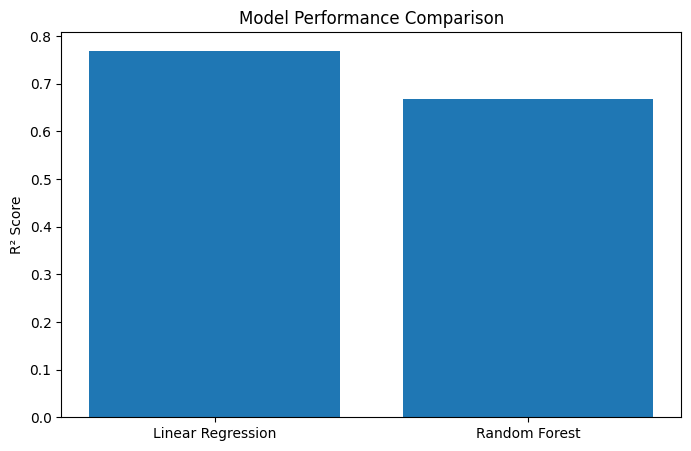

In [ ]:
# Visualize the performance of both models
models = ["Linear Regression", "Random Forest"]
r2_scores = [r2, rf_r2]

plt.figure(figsize=(8, 5))
plt.bar(models, r2_scores)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.show()

In [ ]:
# Determine the best model based on R² score
best_model = model

print("Best Model: Linear Regression")
print("R² Score:", r2)
print("MAE:", mae)
print("MSE:", mse)

Best Model: Linear Regression
R² Score: 0.7696542190277716
MAE: 0.4522783731867862
MSE: 3.255954307905079


In [49]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "R² Score": [r2, rf_r2]
})

print(comparison)

               Model       MAE       MSE  R² Score
0  Linear Regression  0.452278  3.255954  0.769654
1      Random Forest  1.091475  4.687424  0.668383


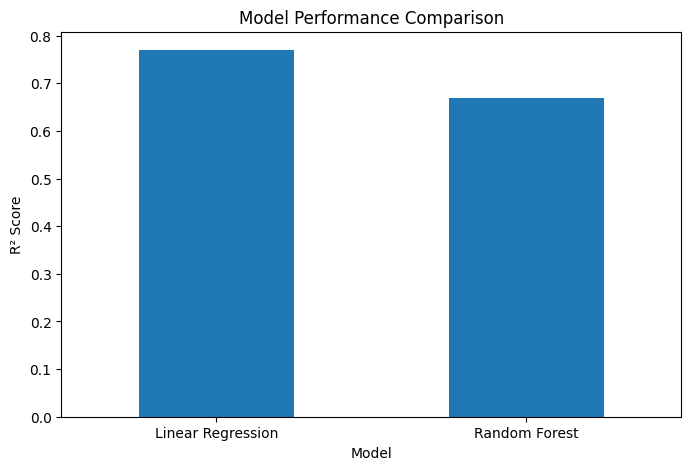

In [50]:
comparison.plot(
    x="Model",
    y="R² Score",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Predicting Exam Score for a New Student

new_student = pd.DataFrame({
    "Hours_Studied": [20],
    "Attendance": [85],
    "Parental_Involvement": ["High"],
    "Access_to_Resources": ["High"],
    "Extracurricular_Activities": ["Yes"],
    "Sleep_Hours": [7],
    "Previous_Scores": [75],
    "Motivation_Level": ["High"],
    "Internet_Access": ["Yes"],
    "Tutoring_Sessions": [2],
    "Family_Income": ["Medium"],
    "Teacher_Quality": ["High"],
    "School_Type": ["Public"],
    "Peer_Influence": ["Positive"],
    "Physical_Activity": [3],
    "Learning_Disabilities": ["No"],
    "Parental_Education_Level": ["College"],
    "Distance_from_Home": ["Near"],
    "Gender": ["Female"]
})

print(new_student)

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             20          85                 High                High   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                        Yes            7               75             High   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Yes                  2        Medium            High   

  School_Type Peer_Influence  Physical_Activity Learning_Disabilities  \
0      Public       Positive                  3                    No   

  Parental_Education_Level Distance_from_Home  Gender  
0                  College               Near  Female  


In [ ]:
# Preprocess the new student data
new_student
new_student_processed = preprocessor.transform(new_student)

predicted_score = best_model.predict(new_student_processed)

print("Predicted Exam Score:", predicted_score[0])

Predicted Exam Score: 72.69090671489214


In [53]:
print(f"Predicted Exam Score: {predicted_score[0]:.2f} / 100")

Predicted Exam Score: 72.69 / 100


In [ ]:
# Function to predict student score
def predict_student_score(student_data):
    student_df = pd.DataFrame([student_data])
    
    student_processed = preprocessor.transform(student_df)
    
    prediction = best_model.predict(student_processed)
    
    return prediction[0]

In [ ]:
# Example usage of the function
def performance_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 60:
        return "Average"
    else:
        return "Needs Improvement"

In [ ]:
# Example usage of the function
score = predict_student_score(new_student.iloc[0].to_dict())
category = performance_category(score)

print(f"Predicted Exam Score: {score:.2f} / 100")
print(f"Performance Category: {category}")

Predicted Exam Score: 72.69 / 100
Performance Category: Good


In [ ]:
# Save the best model to a file
import joblib

joblib.dump(best_model, "student_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Save the preprocessor to a file
joblib.dump(preprocessor, "student_preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [ ]:
# Load the model and preprocessor from files
loaded_model = joblib.load("student_performance_model.pkl")
loaded_preprocessor = joblib.load("student_preprocessor.pkl")

new_student_processed = loaded_preprocessor.transform(new_student)

prediction = loaded_model.predict(new_student_processed)

print(f"Predicted Exam Score: {prediction[0]:.2f}")

Predicted Exam Score: 72.69
